In [1]:
import sys
print(sys.executable)
print(sys.version)

/workspaces/DS-ML-DL-Course-Masters1-MIAS/.venv/bin/python3.12
3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]


In [57]:
                                            ###  SESSION 1  ### 

In [58]:
                                # The data science workflow and first contact with data 

In [36]:
                                        # ÉTAPE 1: Setup and reproducibility

In [37]:
# Path → permet de travailler avec les chemins de fichiers.
# ROOT → retrouve automatiquement la racine du projet.
# sys.path.insert(...) → permet à Python de trouver le dossier src.
# numpy et pandas → bibliothèques utilisées pour l'analyse.
# set_seed(SEED) → fixe la graine aléatoire pour rendre les résultats reproductibles.
# describe_environment() → affiche les versions utilisées.

In [5]:
import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.data import PATHS, SEED, describe_environment, load_raw, set_seed

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print(f"seed = {set_seed(SEED)}")
print(describe_environment().to_string(index=False))

seed = 42
package version
 python  3.12.3
  numpy   2.5.2
 pandas   3.0.5
sklearn   1.9.0


In [6]:
#Pourquoi le train/test split est-il placé en étape 3, avant le nettoyage et l'exploration ?
#Le train/test split est réalisé tôt dans le workflow afin d’éviter la fuite d’information entre les données d’entraînement 
#et les données de test (data leakage). Les décisions de nettoyage, de transformation et de préparation des données doivent être apprises 
#uniquement à partir du jeu d’entraînement, puis appliquées au jeu de test. Cela permet d’obtenir une évaluation plus 
#réaliste des performances du modèle sur de nouvelles données.

In [33]:
                                        # ÉTAPE 2: Les deux clients

In [34]:
# Client A — Direction du Tourisme de Barcelone
#La Direction du Tourisme de Barcelone souhaite identifier les annonces qui fonctionnent sans licence touristique valide 
#afin de pouvoir cibler les inspections.
#L'objectif est donc d'identifier les annonces qui pourraient être non conformes.
#Client B — Société de gestion immobilière
#Une société de gestion immobilière souhaite développer un outil permettant d'estimer le prix de nouveaux logements.
#Elle souhaite notamment savoir :
#Les annonces proposant la réservation instantanée ont-elles un prix plus élevé ?
#Cette question doit être étudiée à partir des données disponibles avant de prendre une décision.

In [32]:
                                    # ÉTAPE 3: The data

In [31]:
#Le jeu de données correspond à un instantané du marché des locations de courte durée à Barcelone.
#Il contient :
#15 293 annonces
#90 colonnes
#Le jeu de données provient d'une collecte de données publiques concernant les annonces Airbnb.
#Il n'a pas été créé spécifiquement pour répondre aux questions de nos deux clients.
#Les noms des colonnes donnent des indications sur leur contenu, mais ils ne doivent pas être considérés automatiquement 
#comme une garantie de la qualité ou de la signification des données.

In [30]:
                                    # ÉTAPE 4: First contact 

In [29]:
df = load_raw()
print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

shape: 15,293 rows x 90 columns


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20260624162917,2026-06-25,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,71615,https://www.airbnb.com/users/show/71615,1.462508e+18,https://www.airbnb.com/users/profile/146250835...,Maria Y Mireia Barcelona4Seasons,NaN,16.0,5.0,15.0,5.0,"Barcelona, Spain","We are Mireia and Maria, two multilingual entr...",NaN,NaN,NaN,f,...,123,2026-06-25,59,9,1,121,9,54,22086.0,2013-05-27,2026-05-28,4.41,4.47,4.59,4.66,4.64,4.83,4.38,Spain - National registration number<br />ESFC...,NaN,20,20,0,0,0.37
1,23197,https://www.airbnb.com/rooms/23197,20260624162917,2026-06-25,city scrape,CCIB Forum· Large Balcony · 5 min walk to CCIB,"Beautiful, spacious apartment with large balco...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,90417,https://www.airbnb.com/users/show/90417,1.462509e+18,https://www.airbnb.com/users/profile/146250935...,Marnie,NaN,16.0,3.0,15.0,5.0,"Catalonia, Spain","Hi there,\n\nI’m marnie, originally from Austr...",NaN,NaN,NaN,t,...,239,2026-06-25,99,11,1,159,11,66,25608.0,2011-03-15,2026-06-07,4.84,4.95,4.91,4.94,4.99,4.69,4.71,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,0.53
2,34981,https://www.airbnb.com/rooms/34981,20260624162917,2026-06-25,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,NaN,https://a0.muscache.com/pictures/c4d1723c-e479...,73163,https://www.airbnb.com/users/show/73163,1.462508e+18,https://www.airbnb.com/users/profile/146250844...,Andres,NaN,16.0,5.0,15.0,5.0,"Barcelona, Spain","Hello I am a Professional designer, a traveler...",NaN,NaN,NaN,t,...,329,2026-06-25,304,37,1,159,33,222,88163.0,2010-10-03,2026-05-26,4.59,4.64,4.68,4.72,4.75,4.65,4.48,Spain - National registration number<br />ESFC...,NaN,2,2,0,0,1.59


In [11]:
#Le jeu de données contient :
#15 293 lignes × 90 colonnes.
#Les 15 293 identifiants d'annonces sont uniques.
#Nous pouvons donc considérer qu'une ligne correspond à une annonce Airbnb.
#Cependant, il ne faut pas considérer les 15 293 lignes comme 15 293 observations totalement indépendantes.
#Il n'y a que 4 595 hôtes différents.
#Certains hôtes possèdent donc plusieurs annonces.
#Par exemple, l'hôte 346367515 possède 588 annonces.
#Cette dépendance entre les annonces est importante pour la séparation entre les données d'entraînement et de test ainsi 
#que pour la validation croisée.

In [12]:
# TODO: Write your three predictions here BEFORE running the next cell.
#
# 1. One row represents:
# 2. Number of completely unusable columns (a number):
# 3. Column with the most missing values:

In [13]:
# 1. One row represents:
print("rows:", f"{len(df):,}")
print("unique listing ids:", f"{df['id'].nunique():,}")
print("unique hosts:      ", f"{df['host_id'].nunique():,}")
print()
print("listings per host, top 5:")
print(df["host_id"].value_counts().head(5).to_string())

rows: 15,293
unique listing ids: 15,293
unique hosts:       4,595

listings per host, top 5:
host_id
346367515    588
1447144      448
21726991     359
32037490     293
4459553      243


In [14]:
#Réponse: Une ligne représente une annonce Airbnb. Le dataset contient 15 293 annonces et les 15 293 identifiants 
#d'annonces sont uniques. En revanche, il n'y a que 4 595 hôtes, et certains hôtes possèdent plusieurs annonces (le plus 
#grand en possède 588).

In [15]:
# 2. Number of completely unusable columns (a number):
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(dropna=True),
})

audit.sort_values("missing_pct", ascending=False).head(20)

,dtype,missing_pct,n_unique
neighborhood_overview,float64,100.0,0
host_since,float64,100.0,0
host_response_time,float64,100.0,0
host_thumbnail_url,float64,100.0,0
host_acceptance_rate,float64,100.0,0
host_response_rate,float64,100.0,0
host_verifications,float64,100.0,0
neighbourhood,float64,100.0,0
host_total_listings_count,float64,100.0,0
host_neighbourhood,float64,100.0,0


In [17]:
#L'audit montre que 12 colonnes sur 90 sont entièrement vides, soit 100 % de valeurs manquantes. Elles sont donc 
#inutilisables telles quelles.

In [18]:
# 3. Column with the most missing values:
#Parmi les colonnes qui contiennent au moins une valeur, host_about est celle qui présente 
#le plus de valeurs manquantes avec 31,8 %. Les autres colonnes fortement incomplètes concernent notamment les salles de 
#bain et plusieurs variables liées aux évaluations des annonces.

In [28]:
                                     # ÉTAPE 4.1: Unusable columns

In [27]:
empty_cols = [c for c in df.columns if df[c].isna().all()]
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]

print(f"{len(empty_cols)} columns are 100% empty:")
for c in empty_cols:
    print(f"    {c}")

print(f"\n{len(constant_cols)} columns are constant: {constant_cols}")
print(f"\nUsable columns: {df.shape[1] - len(set(empty_cols) | set(constant_cols))} of {df.shape[1]}")

12 columns are 100% empty:
    neighborhood_overview
    host_since
    host_response_time
    host_response_rate
    host_acceptance_rate
    host_thumbnail_url
    host_neighbourhood
    host_total_listings_count
    host_verifications
    neighbourhood
    calendar_updated
    instant_bookable

13 columns are constant: ['scrape_id', 'neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'calendar_updated', 'instant_bookable']

Usable columns: 77 of 90


In [20]:
#Le dataset contient 12 colonnes entièrement vides. Elles sont donc inutilisables car elles ne fournissent aucune 
#information. Une colonne supplémentaire, scrape_id, est constante : elle contient une seule valeur pour toutes les 
#observations et n'apporte donc pas d'information permettant de distinguer les annonces. Ainsi, 13 colonnes sont constantes 
#ou entièrement vides, ce qui laisse 77 colonnes utilisables selon ce premier critère.

In [25]:
                                    # ÉTAPE 5:  Guided exercise: the client's question

In [24]:
# TODO: Investigate whether you can answer Client B's question.
#
# Steps:
#   1. Find the column that would let you answer it.
#   2. Check whether it is usable.
#   3. Write the reply you would actually send. Two or three sentences.
#
# Hint: start by searching the column names.

In [39]:
#Nous ne pouvons pas déterminer avec ce jeu de données si les annonces avec réservation instantanée commandent un prix plus 
#élevé. La variable 'instant_bookable', qui serait nécessaire pour faire cette comparaison, est entièrement vide dans notre 
#snapshot. Il faudrait disposer de données complètes sur cette variable, ainsi que d'un prix exploitable, pour pouvoir 
#réaliser cette analyse.

In [22]:
# Step 1: find the relevant column.
candidates = [c for c in df.columns if "instant" in c.lower()]
print("candidate columns:", candidates)

# Step 2: is it usable?
col = "instant_bookable"
print(f"\n{col}:")
print(f"  dtype        : {df[col].dtype}")
print(f"  missing      : {df[col].isna().mean() * 100:.1f}%")
print(f"  unique values: {df[col].nunique(dropna=True)}")
print(f"  value counts :\n{df[col].value_counts(dropna=False).to_string()}")

# Step 3: the reply.
print("""Reply to Client B ----------------- We cannot answer this question with the current data. The snapshot contains an `instant_bookable` field, but it is empty for all 15,293 listings - the 
platform stopped publishing it in this data source. Nothing can be inferred about an instant-booking premium from this 
dataset. Two options: (a) we obtain the field from your own booking system, where it is recorded per listing; or (b) we 
treat this as out of scope and focus on the pricing model, which the available fields do support. We recommend (b) for now
and can revisit (a) if you can export the field.""")

candidate columns: ['instant_bookable']

instant_bookable:
  dtype        : float64
  missing      : 100.0%
  unique values: 0
  value counts :
instant_bookable
NaN    15293
Reply to Client B ----------------- We cannot answer this question with the current data. The snapshot contains an `instant_bookable` field, but it is empty for all 15,293 listings - the 
platform stopped publishing it in this data source. Nothing can be inferred about an instant-booking premium from this 
dataset. Two options: (a) we obtain the field from your own booking system, where it is recorded per listing; or (b) we 
treat this as out of scope and focus on the pricing model, which the available fields do support. We recommend (b) for now
and can revisit (a) if you can export the field.


In [43]:
                # ÉTAPE 6: Independent exercise: the Dataset Fact Sheet (Milestone M0)

In [ ]:
                                        # A. Shape and grain
#Le dataset contient 15 293 lignes et 90 colonnes. Une ligne représente une annonce Airbnb et les 15 293 identifiants 
#d'annonces sont uniques. Cependant, les observations ne sont pas nécessairement indépendantes car 15 293 annonces 
#appartiennent à seulement 4 595 hôtes, certains hôtes possédant plusieurs annonces. Le plus grand hôte possède 588 
#annonces, ce qui doit être pris en compte lors de la séparation train/test et de la validation.

In [44]:
                                        # B. Completeness
audit[audit["missing_pct"] < 100].sort_values(
    "missing_pct", ascending=False
).head(3)

,dtype,missing_pct,n_unique
host_about,str,31.8,2406
bathrooms,float64,23.3,21
review_scores_location,float64,23.2,134


In [ ]:
#Le dataset contient 12 colonnes entièrement vides, soit 100 % de valeurs manquantes. Parmi les colonnes qui sont 
#partiellement renseignées, les trois plus incomplètes sont host_about avec 31,8 % de valeurs manquantes, bathrooms avec 
#23,3 % et review_scores_location avec 23,2 %. Ces valeurs manquantes devront être prises en compte avant toute utilisation 
#de ces variables dans un modèle.

In [45]:
                                    # C. Types
df.dtypes.to_string()

'id                                                int64\nlisting_url                                         str\nscrape_id                                         int64\nlast_scraped                                        str\nsource                                              str\nname                                                str\ndescription                                         str\nneighborhood_overview                           float64\npicture_url                                         str\nhost_id                                           int64\nhost_url                                            str\nhost_profile_id                                 float64\nhost_profile_url                                    str\nhost_name                                           str\nhost_since                                      float64\nhosts_time_as_user_years                        float64\nhosts_time_as_user_months                       float64\nhosts_time_as_host_years      

In [46]:
#Deux types de variables nécessitent une attention particulière. La colonne price est stockée comme une chaîne de caractères
#(str) alors qu'elle représente une valeur numérique correspondant au prix d'une annonce ; elle devra donc être nettoyée et 
#convertie avant une analyse numérique. De même, plusieurs variables comme first_review, last_review et last_scraped sont 
#stockées comme str alors qu'elles représentent des dates. Elles devraient être converties dans un format de date afin de 
#pouvoir effectuer correctement des opérations temporelles.

In [47]:
                                    # D. Questions
#Les données permettent d'étudier plusieurs questions, par exemple : (1) comment le prix des annonces varie selon le type 
#de logement, (2) s'il existe une association entre la note des annonces et le nombre d'avis, et (3) comment la 
#disponibilité des logements varie selon leur type. En revanche, les données ne permettent pas de déterminer si les 
#annonces avec réservation instantanée ont un prix plus élevé, car la variable instant_bookable est entièrement vide dans 
#ce snapshot. Cette question nécessiterait des données complètes sur la réservation instantanée et un prix exploitable.

In [48]:
                                    # E. Problem statement
#CLIENT A: Pour la Direction du Tourisme de Barcelone, l'unité d'observation est une annonce Airbnb. L'objectif est 
#d'identifier les annonces susceptibles de fonctionner sans licence touristique valide afin d'aider les services 
#d'inspection à cibler leurs contrôles. La cible serait donc le statut de conformité de l'annonce. Le succès serait une 
#sélection d'annonces suffisamment fiable et défendable pour permettre aux services concernés de concentrer leurs 
#ressources d'inspection, plutôt que de simplement maximiser un score de performance du modèle.

#CLIENT B: Pour la société de gestion immobilière, l'unité d'observation est une annonce ou un appartement. L'objectif 
#est d'estimer le prix auquel une nouvelle annonce pourrait être proposée à partir de ses caractéristiques. La cible 
#serait donc le prix de l'annonce. Le succès serait d'obtenir une estimation suffisamment proche des prix pertinents du 
#marché pour aider l'entreprise à fixer un prix de mise en location, et non simplement d'obtenir une bonne performance sur 
#une métrique de régression.

In [49]:
# TODO: Section A - shape and grain.
# Print the shape, then work out how many genuinely independent units there are.

#Taille : 15 293 lignes × 90 colonnes.
#Grain : une ligne représente une annonce Airbnb. Les 15 293 identifiants d'annonces sont uniques.
#Unités indépendantes : les lignes ne sont pas nécessairement indépendantes, car il y a seulement 4 595 hôtes pour 
#15 293 annonces. Certains hôtes possèdent donc plusieurs annonces, le plus grand hôte en possédant 588. Cela est important 
#pour la séparation entre les données d'entraînement et de test ainsi que pour la validation croisée, car les annonces d'un 
#même hôte ne doivent pas être considérées comme totalement indépendantes.

In [50]:
# TODO: Section B - completeness.
# List the unusable columns, then the three worst *partially* missing columns.

#Colonnes inutilisables : 12 colonnes sont entièrement vides, avec 100 % de valeurs manquantes :
#`neighborhood_overview`, `host_since`, `host_response_time`, `host_response_rate`, `host_acceptance_rate`, 
#`host_thumbnail_url`, `host_neighbourhood`, `host_total_listings_count`, `host_verifications`, `neighbourhood`, 
#`calendar_updated` et `instant_bookable`.
#Colonnes partiellement renseignées présentant le plus de valeurs manquantes :
#`host_about` : 31,8 %
#`bathrooms` : 23,3 %
#`review_scores_location` : 23,2 %
#De plus, la colonne `scrape_id` est constante et ne fournit donc aucune information permettant de différencier les 
#observations.

In [51]:
# TODO: Section C - types.
# Find at least two columns whose dtype does not match their content.
# Print a few example values as evidence for each.

#Deux types de variables nécessitent une attention particulière.
#`price` est stockée comme une chaîne de caractères (`str`) alors qu'elle représente un prix numérique. Elle devra donc 
#être nettoyée et convertie en valeur numérique avant une analyse ou une modélisation.
#`first_review`, `last_review` et `last_scraped` sont stockées comme des chaînes de caractères (`str`) alors qu'elles 
#représentent des dates. Elles devraient être converties dans un format de date (`datetime`) pour permettre des analyses 
#temporelles.
#Ces variables ne sont pas forcément inutilisables, mais leur représentation actuelle n'est pas adaptée aux traitements 
#correspondants.

In [42]:
                            # ÉTAPE 7: Debate: regression or classification?

In [52]:
#Différence entre classification et régression
#Classification: prédire une categorie
#Régression: prédire une valeur numerique continue
#Regarder la distribution des donnees dans la classe si c'est une classification binaire ou multiclasse en regardant la 
#distribution des valeurs uniques de chaque clqsse et les comparer

In [53]:
#Pour le Client A, il s'agit d'un problème de classification. L'unité d'observation est une annonce Airbnb et la cible 
#correspond au statut de conformité de l'annonce par rapport à sa licence touristique. Le résultat utile pour le client 
#serait une sélection d'annonces à cibler pour les inspections, accompagnée d'une estimation suffisamment fiable pour 
#justifier ces choix.

#Pour le Client B, il s'agit d'un problème de régression. L'unité d'observation est une annonce ou un appartement et la 
#cible est son prix. Le résultat utile pour le client serait une estimation de prix suffisamment proche des prix pertinents 
#du marché pour aider à fixer le prix d'une nouvelle annonce.

In [54]:
                        # ÉTAPE 8:  Common mistakes in this session

In [55]:
#Plusieurs erreurs doivent être évitées. Il ne faut pas considérer toutes les lignes comme indépendantes, car plusieurs 
#annonces peuvent appartenir au même hôte. Il ne faut pas non plus se fier uniquement au nom d'une colonne : par exemple, 
#`instant_bookable` semble pertinente pour la question du Client B mais elle est entièrement vide. De même, l'observation 
#de quelques lignes avec `head()` ne permet pas d'évaluer la qualité globale des données. Enfin, le succès d'un projet ne 
#doit pas être défini uniquement par une métrique et il est préférable de comprendre et préparer les données avant de 
#commencer la modélisation.

In [59]:
                                # ÉTAPE 9:  Reflection

In [60]:
#1. Une colonne peut être inutilisable même si elle ne contient aucune valeur manquante. Elle peut être constante, avoir 
#un mauvais type, contenir des valeurs incohérentes ou aberrantes, ou encore être redondante avec une autre variable. Par 
#exemple, `scrape_id` n'a pas de valeurs manquantes mais elle est constante, donc elle n'apporte aucune information pour 
#distinguer les annonces.

#2. Les données ne sont pas neutres : elles proviennent d'un projet de collecte portant sur les locations Airbnb et n'ont 
#pas été recueillies spécifiquement pour répondre aux besoins de nos deux clients. Elles reflètent donc les informations 
#rendues publiques sur la plateforme ainsi que les choix et les limites du processus de collecte. Deux clients peuvent 
#ainsi utiliser le même dataset pour des objectifs différents et parvenir à des conclusions différentes selon leurs 
#intérêts et leurs questions.

#3. Je voudrais vérifier ensuite la qualité, la distribution et la cohérence des variables qui pourraient être utilisées 
#comme cible, ainsi que leur relation avec les principales variables explicatives. Cela permettrait de vérifier qu'elles 
#sont suffisamment informatives et adaptées au problème avant de commencer la modélisation.

In [61]:
                                    # ÉTAPE 10: Knowledge check

In [62]:
#1. One row of this dataset is one __Observations____, and there are __15,293 listings____ of them.

#2. There are 4,595 hosts and 15,293 listings. Why does that gap matter for a train/test split?
#L’écart montre qu’un même hôte peut posséder plusieurs annonces. Les lignes ne sont donc pas nécessairement indépendantes. 
#Si on fait une séparation aléatoire classique, les annonces d’un même hôte peuvent se retrouver à la fois dans l’ensemble 
#d’entraînement et dans l’ensemble de test. Cela peut provoquer une fuite d’information (data leakage) et donner des 
#performances trop optimistes.

#3. A column has dtype=object and 0% missing values. Name two distinct reasons it might still be unusable as a model input.
#Une variable de type object sans valeur manquante peut quand même être inutilisable directement pour un modèle :
#elle peut contenir du texte, une URL ou une date sous forme de chaîne, qui nécessite une transformation avant d’être 
#utilisée ;
#elle peut contenir un identifiant ou une information peu pertinente, qui n’apporte pas de véritable information prédictive 
#et peut même conduire le modèle à mémoriser les observations.
#Ainsi, l’absence de valeurs manquantes ne signifie pas qu’une variable est automatiquement exploitable.

#4. At which stage of the workflow does the train/test split belong, and what does placing it later cost you?
#Le train/test split doit être effectué à l’étape 3, avant le nettoyage, l’analyse exploratoire et la création des 
#variables. Si on effectue la séparation plus tard, certaines opérations de préparation peuvent utiliser indirectement des 
#informations provenant de l’ensemble de test. Cela provoque une fuite d’information (data leakage) et peut conduire à des 
#performances artificiellement élevées sur le test.

#5. Client A wants to target inspections. Give one success criterion that is not a model metric.
#Pour le Client A, le succès signifie être capable de cibler de manière défendable les annonces susceptibles de ne pas 
#respecter les règles de licence, afin d'utiliser efficacement les ressources limitées consacrées aux inspections.
#Le succès ne se résume donc pas à obtenir une bonne accuracy ou un bon F1-score : le résultat doit surtout permettre de 
#sélectionner des annonces à inspecter de manière fiable et justifiable.

In [63]:
                                            ### SESSION 2 ###

In [64]:
                                        # Data Quality, the Split-First Rule & Visual Reasoning

In [65]:
                                        # ÉTAPE 1: Retrieval practice

In [66]:
import sys
from pathlib import Path

# Same root-finding walk as Session 1: make src/ importable wherever we launched.
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# split_by_host is the grouped split we are about to justify from first principles.
from src.data import PATHS, SEED, load_raw, set_seed, split_by_host

# One consistent visual style for every chart in the session, set once.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
# Seed before anything random happens, including the split below.
set_seed(SEED)

df = load_raw()
print(f"loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

loaded 15,293 rows x 90 columns


In [74]:
                                    # ÉTAPE 2: The split, first

In [68]:
# The structure that decides how we are allowed to split. Counting rows per host is
# the whole argument: if one host owns hundreds of listings, those rows are not
# independent draws, and a random split will scatter one host across both halves.
hosts = df["host_id"].value_counts()
print(f"listings                    : {len(df):,}")
print(f"hosts                       : {hosts.size:,}")
# hosts > 1 selects the multi-listing hosts; .sum() over their counts converts that
# back into a number of rows, which is the share of the data at risk.
print(f"listings from multi-listing hosts: {hosts[hosts > 1].sum():,} "
      f"({hosts[hosts > 1].sum() / len(df) * 100:.1f}%)")
print(f"largest single host         : {hosts.max()} listings")

listings                    : 15,293
hosts                       : 4,595
listings from multi-listing hosts: 12,305 (80.5%)
largest single host         : 588 listings


In [69]:
# Prediction: environ 90 à 95 % des listings du test partageront leur host avec le train.

In [70]:
from sklearn.model_selection import train_test_split

# The default split everyone reaches for, done correctly as far as the API goes:
# 20% held out, seeded, reproducible. The problem is not the code, it is the
# assumption underneath it that rows are interchangeable.
naive_train, naive_test = train_test_split(df, test_size=0.2, random_state=SEED)
# Set intersection: which host ids ended up on both sides of the wall.
shared_hosts = set(naive_train["host_id"]) & set(naive_test["host_id"])
# isin() turns that set into a row-level mask over the test half.
contaminated = naive_test["host_id"].isin(shared_hosts)

print("NAIVE RANDOM SPLIT")
print(f"  hosts appearing in BOTH halves : {len(shared_hosts):,}")
# Read this percentage out loud before revealing it. It is the point of the section:
# these test rows have a sibling in training, so the test set is measuring memory.
print(f"  test listings whose host is also in train: "
      f"{contaminated.sum():,} of {len(naive_test):,} ({contaminated.mean() * 100:.1f}%)")

NAIVE RANDOM SPLIT
  hosts appearing in BOTH halves : 875
  test listings whose host is also in train: 2,382 of 3,059 (77.9%)


In [71]:
# TODO: Split by host so that no host_id appears in both halves.
#
# Use sklearn.model_selection.GroupShuffleSplit with:
#     n_splits=1, test_size=0.2, random_state=SEED
# and groups=df["host_id"].
#
# Then print: train rows, test rows, train hosts, test hosts, and the number of
# hosts appearing in both (which must be 0).

train = None   # replace
test = None    # replace

In [72]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED
)

train_idx, test_idx = next(
    gss.split(df, groups=df["host_id"])
)

train = df.iloc[train_idx].copy()
test = df.iloc[test_idx].copy()

train_hosts = set(train["host_id"])
test_hosts = set(test["host_id"])

print(f"train rows : {len(train):,}")
print(f"test rows  : {len(test):,}")
print(f"train hosts: {len(train_hosts):,}")
print(f"test hosts : {len(test_hosts):,}")
print(f"shared hosts: {len(train_hosts & test_hosts)}")

train rows : 12,626
test rows  : 2,667
train hosts: 3,676
test hosts : 919
shared hosts: 0


In [78]:
##Code du prof

from sklearn.model_selection import GroupShuffleSplit
# GroupShuffleSplit shuffles and splits the *groups*, not the rows. Every listing
# belonging to a host travels with that host, so no host can straddle the wall.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
# .split() is a generator yielding index arrays; n_splits=1 means we want the first
# and only pair, hence next().
train_idx, test_idx = next(splitter.split(df, groups=df["host_id"]))
# .iloc takes positional indices. .copy() detaches the halves from df so later
# assignments do not raise SettingWithCopyWarning or silently write through.
train, test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
overlap = set(train["host_id"]) & set(test["host_id"])
print("GROUPED SPLIT")
# Note the row percentages are no longer exactly 80/20. Groups have different sizes,
# so you buy independence at the cost of an exact split ratio. That is the right
# trade, and it is worth saying so out loud.
print(f"  train : {len(train):,} rows ({len(train) / len(df) * 100:.1f}%), "
      f"{train['host_id'].nunique():,} hosts")
print(f"  test  : {len(test):,} rows ({len(test) / len(df) * 100:.1f}%), "
      f"{test['host_id'].nunique():,} hosts")
print(f"  hosts in both halves: {len(overlap)}")

GROUPED SPLIT
  train : 12,626 rows (82.6%), 3,676 hosts
  test  : 2,667 rows (17.4%), 919 hosts
  hosts in both halves: 0


In [73]:
# Sealing the test set
PATHS.sealed.mkdir(parents=True, exist_ok=True)

sealed_path = PATHS.sealed / "test.parquet"

test.to_parquet(sealed_path, index=False)

print(f"sealed {len(test):,} rows -> {sealed_path.relative_to(PATHS.root)}")

print(f"file size: {sealed_path.stat().st_size / 1e6:.1f} MB")

print("\nFrom this point on, `train` is your entire world.")

del test

sealed 2,667 rows -> data/SEALED_TEST/test.parquet
file size: 1.6 MB

From this point on, `train` is your entire world.


In [75]:
                            # ÉTAPE 3: Six categories of data-quality defect

In [80]:
##Defect 1: wrong type

In [77]:
# Why price cannot be used as it stands. The dtype says "object", which for pandas
# means text, and the examples show why: a currency symbol and thousands separators.
print("price, as stored:")
print(f"  dtype   : {train['price'].dtype}")
print(f"  examples: {train['price'].dropna().head(4).tolist()}")

# Deliberately triggering the error rather than describing it. Let the class read
# the actual TypeError, because that is the message they will meet on their own.
try:
    train["price"].mean()
except TypeError as exc:
    print(f"\n  train['price'].mean() -> TypeError: {exc}")

price, as stored:
  dtype   : str
  examples: ['$409.00', '$388.00', '$397.13', '$226.13']

  train['price'].mean() -> TypeError: Cannot perform reduction 'mean' with string dtype


In [79]:
# Parsing price, one step at a time, and each step is a decision.
price = (
    train["price"]
    # astype(str) so the regex applies uniformly even where pandas stored NaN.
    .astype(str)
    # Strip everything that is not a digit or a decimal point: the currency symbol
    # and the thousands separators go, the number survives.
    .str.replace(r"[^0-9.]", "", regex=True)
    # A row that was empty to begin with is now the empty string, which would crash
    # the conversion. Send it back to NaN, where it belongs.
    .replace("", np.nan)
    .astype(float)
)
# assign() returns a new frame rather than mutating train in place, which keeps the
# original column available for comparison.
train = train.assign(price_num=price)

print(f"parsed {price.notna().sum():,} prices; {price.isna().mean() * 100:.1f}% missing")
# The percentiles matter more than the mean here. The 99th against the max is the
# first sign of how long the right tail is.
print(price.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2).to_string())

parsed 11,031 prices; 12.6% missing
count    11031.00
mean       247.53
std        352.89
min          3.50
1%          24.17
25%         90.28
50%        178.00
75%        286.00
99%       1895.00
max       7532.00


In [81]:
##Defects 3 and 4: impossible values, and outliers

In [82]:
# Implausible values, counted rather than eyeballed. Each line below is a different
# kind of defect, and none of them is a missing value.
print(f"prices over  €1,000 : {(price > 1000).sum():,}")
print(f"prices over  €5,000 : {(price > 5000).sum():,}")
print(f"maximum price       : €{price.max():,.2f}")
# Zero is not missing, it is a claim. A free flat is a data defect, not a bargain.
print(f"prices at zero      : {(price == 0).sum()}")
# A listing that sleeps nobody is impossible, so this is a recording artifact.
print(f"accommodates == 0   : {(train['accommodates'] == 0).sum()}")
# A minimum stay beyond a year is how a host hides a listing without delisting it.
# The value is real, but it does not mean what the column name suggests.
print(f"minimum_nights > 365: {(train['minimum_nights'] > 365).sum()} "
      f"(max {train['minimum_nights'].max():.0f})")

# nlargest is the fastest way to look at the tail. Look at the other columns too:
# the question is whether these listings are errors or simply unusual properties.
train.nlargest(5, "price_num")[
    ["price_num", "room_type", "accommodates", "bedrooms", "neighbourhood_cleansed"]
]

prices over  €1,000 : 268
prices over  €5,000 : 5
maximum price       : €7,532.00
prices at zero      : 0
accommodates == 0   : 0
minimum_nights > 365: 3 (max 900)


,price_num,room_type,accommodates,bedrooms,neighbourhood_cleansed
12321,7532.0,Entire home/apt,16,12.0,la Dreta de l'Eixample
12139,7293.0,Entire home/apt,16,12.0,la Dreta de l'Eixample
12155,6151.0,Entire home/apt,16,14.0,la Dreta de l'Eixample
12112,6106.0,Entire home/apt,16,15.0,la Dreta de l'Eixample
10137,5900.0,Entire home/apt,16,10.0,la Dreta de l'Eixample


In [83]:
##Defect 6: deceptive duplicates
# Duplicates, and why the obvious test finds nothing useful here.
# duplicated() compares whole rows, and whole rows differ by id, so this is near zero.
print(f"exact duplicate rows: {train.duplicated().sum()}")

# The interesting test uses a business key: same coordinates, same room type, same
# capacity. Two rows matching on all four are describing the same physical space.
key = ["latitude", "longitude", "room_type", "accommodates"]
# keep=False marks every member of a duplicated group, not just the repeats, which
# is what we want when we are trying to see the groups themselves.
dup_mask = train.duplicated(subset=key, keep=False)
print(f"rows sharing (lat, lon, room_type, accommodates): {dup_mask.sum():,}")

# The decisive question: are these one host listing a unit several times, or
# different hosts colliding by chance? Counting distinct hosts per group answers it.
groups = train[dup_mask].groupby(key)["host_id"].nunique()
print(f"  such groups              : {len(groups):,}")
# A group with one host is a multi-unit operator, not a data error. Deleting these
# rows would quietly delete the professional operators, which is exactly the
# population the regulator cares about.
print(f"  groups with a single host: {(groups == 1).sum():,} "
      f"({(groups == 1).mean() * 100:.0f}%)")

exact duplicate rows: 0
rows sharing (lat, lon, room_type, accommodates): 1,330
  such groups              : 420
  groups with a single host: 392 (93%)


In [85]:
### Conclusions sur les six défauts de qualité

#### Défaut 1 — Mauvais type
#La variable `price` était stockée sous forme de texte (`str`) alors qu'elle représente une valeur numérique. Cette 
#mauvaise représentation empêchait notamment de calculer directement la moyenne. Nous avons donc créé une variable 
#numérique `price_num` en supprimant les caractères non numériques. Après conversion, 11 031 prix sont exploitables et 
#12,6 % restent manquants.

#### Défaut 2 — Plusieurs informations dans une même cellule
#Certaines variables peuvent contenir plusieurs informations dans une même cellule et doivent être transformées avant 
#d'être utilisées dans une analyse ou un modèle. Pour `bathrooms_text`, il faudra notamment extraire le nombre de salles 
#de bain afin d'obtenir une variable numérique exploitable, tout en prenant en compte les valeurs particulières comme les 
#demi-salles de bain.

#### Défaut 3 — Valeurs impossibles
#Aucune annonce ne présente un prix égal à zéro ni une capacité d'accueil égale à zéro. En revanche, trois annonces ont un 
#`minimum_nights` supérieur à 365 jours, avec un maximum de 900 jours. Ces valeurs sont potentiellement anormales et 
#doivent être signalées et examinées plutôt que supprimées automatiquement.

#### Défaut 4 — Valeurs extrêmes / outliers
#La variable `price_num` présente une forte dispersion : 268 annonces ont un prix supérieur à 1 000 € et 5 dépassent 
#5 000 €, avec un maximum de 7 532 €. Cependant, les cinq annonces les plus chères correspondent à de grands logements 
#entiers pouvant accueillir 16 personnes dans la Dreta de l'Eixample. Ces valeurs peuvent donc être légitimes. Nous 
#choisirons de les signaler plutôt que de les supprimer, afin de conserver l'information et de pouvoir étudier leur 
#influence ultérieurement.

#### Défaut 5 — Valeurs manquantes
#Les valeurs manquantes ne doivent pas être traitées de la même manière sans comprendre leur origine. Pour `price`, environ
#12,6 % des valeurs sont manquantes après conversion. Pour `review_scores_rating`, l'absence de valeur est liée à l'absence
#d'avis et constitue donc une absence d'information structurelle plutôt qu'une donnée manquante aléatoire. Il est donc 
#préférable d'identifier le mécanisme de chaque variable avant de choisir entre imputation, indicateur de manque ou 
#suppression.

#### Défaut 6 — Doublons trompeurs
#Aucun doublon exact n'a été détecté. Cependant, 1 330 lignes partagent les mêmes coordonnées, le même type de logement et 
#la même capacité d'accueil, réparties dans 420 groupes. Dans 93 % de ces groupes, les annonces appartiennent au même hôte. 
#Ces observations peuvent correspondre à plusieurs logements distincts gérés par un même opérateur. Il serait donc 
#dangereux de les supprimer automatiquement avec `drop_duplicates()`.

### Conclusion générale
#La qualité des données ne consiste pas seulement à supprimer les valeurs anormales ou les doublons. Chaque anomalie doit 
#être examinée afin de comprendre son origine et son impact. Dans notre cas, nous privilégions une approche réversible : 
#convertir les variables mal typées, documenter les valeurs suspectes, conserver les valeurs extrêmes lorsqu'elles peuvent 
#être légitimes et comprendre le mécanisme des valeurs manquantes avant de les traiter.

In [86]:
            # ÉTAPE 4: Guided exercise: build a cleaning function with a decision log

In [87]:
# TODO: Complete the cleaning function.
#
# Requirements:
#   - parse price into a numeric column
#   - drop columns that are entirely empty, and constant columns
#   - handle bathrooms_text -> a numeric bathroom count (look at the values first!)
#   - decide what to do about extreme prices, and DO NOT silently drop rows
#   - return the cleaned frame; do not mutate the input
#
# Rules:
#   - every decision gets a line in your log
#   - no step may use information from outside `df`


def clean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 1. price -> numeric
    # TODO

    # 2. drop empty and constant columns
    # TODO

    # 3. bathrooms_text -> numeric
    # TODO

    # 4. extreme prices: flag, don't silently drop
    # TODO

    return out

In [88]:
def clean(df: pd.DataFrame) -> pd.DataFrame:

    """Cleaning for the Barcelona listings. Every step is logged in §4's table."""
    # copy() first, so the function is a pure transformation. Cleaning that mutates
    # its input cannot be re-run, and a step you cannot re-run you cannot debug.
    out = df.copy()
    # 1. price: currency-formatted text -> float
    out["price_num"] = (
        out["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
        .replace("", np.nan).astype(float)
    )
    # 2. drop columns carrying no information
    empty = [c for c in out.columns if out[c].isna().all()]
    constant = [c for c in out.columns if out[c].nunique(dropna=True) <= 1]
    # The union deduplicates: an all-missing column satisfies both tests, and
    # dropping the same name twice would raise.
    out = out.drop(columns=sorted(set(empty) | set(constant)))
    # 3. bathrooms_text -> numeric. "1 shared bath" -> 1.0, "Half-bath" -> 0.5
    txt = out["bathrooms_text"].astype(str).str.lower()
    # Pull the leading number out of the text. [0] takes the first capture group,
    # and rows with no number become NaN rather than raising.
    n = txt.str.extract(r"([\d.]+)")[0].astype(float)
    # "Half-bath" contains no digit at all, so the regex left NaN. where() keeps the
    # existing value where the condition holds and substitutes 0.5 where it does not.
    n = n.where(~txt.str.contains("half", na=False), 0.5)
    out["bathrooms_n"] = n
    # Shared or private is a second fact hiding in the same text field. Extract it
    # rather than discarding it: it is one of the few honest quality signals here.
    out["bath_is_shared"] = txt.str.contains("shared", na=False)
    # 4. extreme prices: FLAG, never silently drop. Scoping is a modelling
    #    decision and belongs to the modelling notebook, not to cleaning.
    out["price_implausible"] = out["price_num"] > 2000
    return out
clean_train = clean(train)
print(f"before: {train.shape}   after: {clean_train.shape}")
# The +3 corrects for the three columns the function added, so the number printed
# is the count actually dropped rather than the net change.
print(f"columns dropped: {train.shape[1] - clean_train.shape[1] + 3}")
print(f"flagged as implausible price: {clean_train['price_implausible'].sum()}")
# Never trust a text parser without reading its output. These six rows are the
# evidence that the bathroom rules did what the comment claims.
print("\nbathrooms parsing check:")
print(clean_train[["bathrooms_text", "bathrooms_n", "bath_is_shared"]].dropna().head(6).to_string(index=False))

before: (12626, 91)   after: (12626, 81)
columns dropped: 13
flagged as implausible price: 96

bathrooms parsing check:
bathrooms_text  bathrooms_n  bath_is_shared
       2 baths          2.0           False
       2 baths          2.0           False
       3 baths          3.0           False
        1 bath          1.0           False
        1 bath          1.0           False
     3.5 baths          3.5           False


In [90]:
#### Conclusion sur la fonction de nettoyage
#La fonction `clean()` conserve les 12 626 observations du jeu d'entraînement et supprime les colonnes entièrement vides 
#ou constantes. Les prix sont convertis en valeurs numériques et les valeurs potentiellement implausibles sont signalées 
#sans être supprimées. La variable `bathrooms_text` est également transformée en une variable numérique `bathrooms_num`, 
#tout en conservant l'information concernant les salles de bain partagées. Cette approche permet de conserver les données 
#et de rendre les décisions de nettoyage réversibles et traçables.

In [89]:
                    # ÉTAPE 5: Missingness lab: two mechanisms, measurably different

In [91]:
# Two columns with missing values, and the rates alone tell you nothing about what
# to do. The mechanism behind the gap is what decides the treatment.
for col in ["review_scores_rating", "price"]:
    print(f"{col:24s} {df[col].isna().mean() * 100:5.1f}% missing")

review_scores_rating      23.2% missing
price                     12.7% missing


In [92]:
#Missingness lab: two mechanisms, measurably different
#une technique qui consiste a remplacer les valeurs manquantes par la moyenne (a verifier)

#Case 1 - review_scores_rating
# Diagnosing the mechanism: compare the rows that are missing against the rows that
# are not, on a column that might explain the gap.
miss = train["review_scores_rating"].isna()
print("mean number_of_reviews:")
# .loc[mask, col] selects the rows where the mask is True and that one column.
print(f"  where rating is missing: {train.loc[miss, 'number_of_reviews'].mean():.2f}")
print(f"  where rating is present: {train.loc[~miss, 'number_of_reviews'].mean():.2f}")
print()
# The decisive line. A rating is missing because there were no reviews to average,
# so the value is not unknown, it is undefined. Imputing the mean rating here would
# invent a reputation for a listing that has never been rated.
print(f"share with ZERO reviews, among missing: "
      f"{(train.loc[miss, 'number_of_reviews'] == 0).mean() * 100:.1f}%")
print(f"share with ZERO reviews, among present: "
      f"{(train.loc[~miss, 'number_of_reviews'] == 0).mean() * 100:.1f}%")

mean number_of_reviews:
  where rating is missing: 0.00
  where rating is present: 85.55

share with ZERO reviews, among missing: 100.0%
share with ZERO reviews, among present: 0.0%


In [93]:
#Case 2 - price - now measure the bias
pm = train["price_num"].isna()
print(f"price missing: {pm.sum():,} rows ({pm.mean() * 100:.1f}%)\n")

# The same missing-versus-present comparison as above, widened to four columns and
# laid out as a table so the differences can be read down a column.
comparison = pd.DataFrame({
    "price_missing": [
        train.loc[pm, "availability_365"].mean(),
        train.loc[pm, "number_of_reviews"].mean(),
        # A boolean mean is a proportion, so multiplying by 100 gives a percentage.
        (train.loc[pm, "room_type"] == "Private room").mean() * 100,
        train.loc[pm, "accommodates"].mean(),
    ],
    "price_present": [
        train.loc[~pm, "availability_365"].mean(),
        train.loc[~pm, "number_of_reviews"].mean(),
        (train.loc[~pm, "room_type"] == "Private room").mean() * 100,
        train.loc[~pm, "accommodates"].mean(),
    ],
}, index=["mean availability_365", "mean number_of_reviews",
          "% private rooms", "mean accommodates"])
# The difference column is what makes the table readable at a glance.
comparison["difference"] = comparison["price_present"] - comparison["price_missing"]
print(comparison.round(1).to_string())

# The benchmark for the private-room row above. If the missing rows were a random
# sample, their share would sit on this number. It does not, so dropping them would
# change the population being modelled, quietly and in a direction we can name.
print(f"\nOverall private-room share: "
      f"{(train['room_type'] == 'Private room').mean() * 100:.1f}%")

price missing: 1,595 rows (12.6%)

                        price_missing  price_present  difference
mean availability_365            39.7          240.3       200.6
mean number_of_reviews           28.9           70.4        41.5
% private rooms                  60.8           22.8       -38.1
mean accommodates                 2.6            3.9         1.3

Overall private-room share: 27.6%


In [94]:
                                    # ÉTAPE 6: Visual reasoning

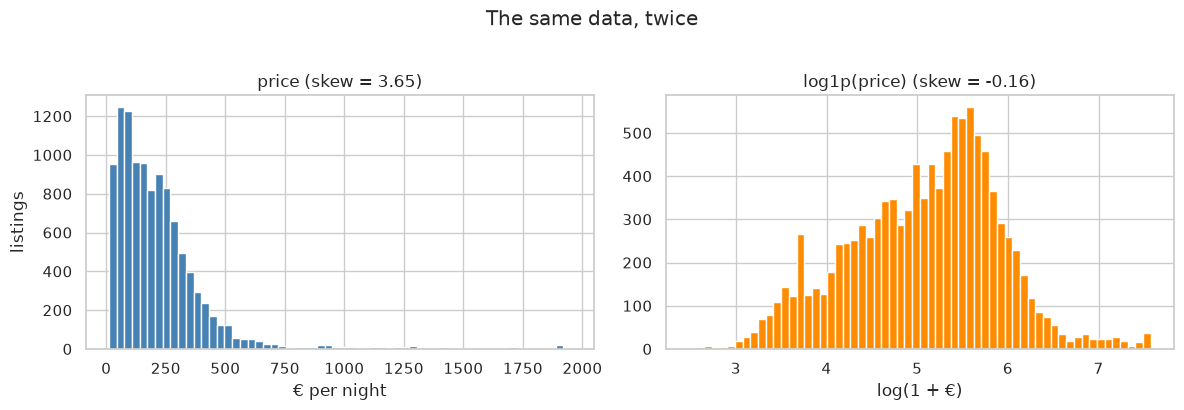

In [95]:
# Why a transformation, shown rather than asserted. between() scopes to a plausible
# range so the chart is about the shape of the distribution, not about one outlier.
valid = train.loc[train["price_num"].between(10, 2000), "price_num"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Left: the raw prices. skew() is printed in the title so the shape has a number
# attached to it rather than only an impression.
axes[0].hist(valid, bins=60, color="steelblue")
axes[0].set(title=f"price (skew = {valid.skew():.2f})", xlabel="€ per night",
            ylabel="listings")
# Right: the same values through log1p, which is log(1 + x) and so is defined at
# zero. On a multiplicative quantity such as price this turns a long right tail
# into something close to symmetric, which is what linear models expect.
axes[1].hist(np.log1p(valid), bins=60, color="darkorange")
axes[1].set(title=f"log1p(price) (skew = {np.log1p(valid).skew():.2f})",
            xlabel="log(1 + €)")
# Same data in both panels. Only the scale changed, and the skew numbers show how
# much that alone bought us.
fig.suptitle("The same data, twice", y=1.02)
plt.tight_layout()
plt.show()

In [96]:
# TODO: Produce three charts. For each one, write in a comment:
#        (a) the question it answers
#        (b) one thing it cannot tell you
#
# 1. A bivariate chart comparing log price across the four room types.
# 2. A multivariate chart: price vs accommodates, split by room type.
# 3. A chart of your own choosing that answers a question you actually have.

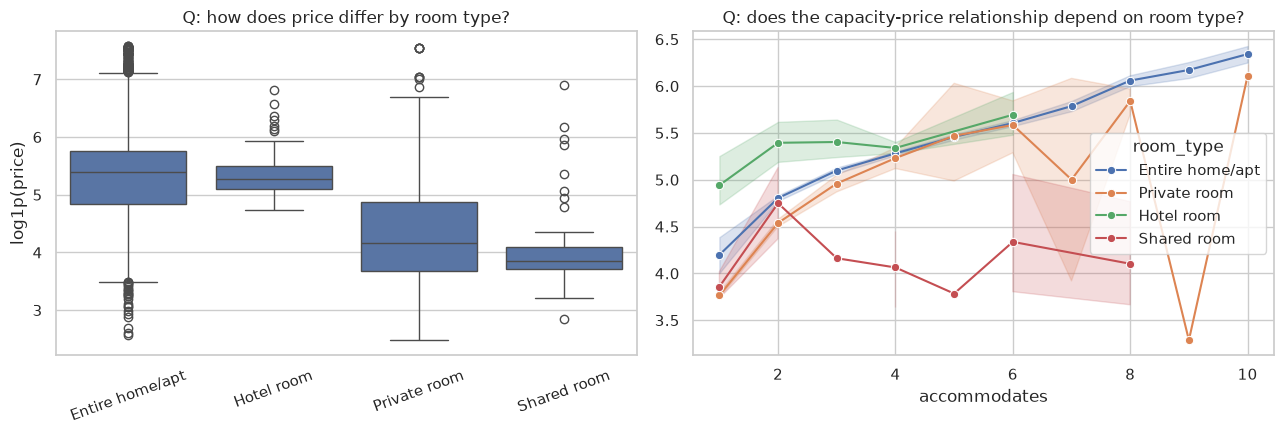


Chart 1 answers: which room types command higher nightly prices, and how much
  spread is there within each type.
Chart 1 CANNOT tell you: whether room type *causes* the difference. Entire homes
  are also bigger and in different neighbourhoods. This is a comparison, not an
  effect.

Chart 2 answers: price rises with capacity, and the slope differs by room type -
  an interaction.
Chart 2 CANNOT tell you: anything reliable about shared rooms at high capacity;
  there are only 119 shared rooms in total, so those intervals are very wide.
  Always check the n behind a line.



In [97]:
#Code du prof
# Scope once, transform once, then plot. Doing it in a lambda inside assign() keeps
# the modelling frame separate from the plotting frame.
plot_df = train.loc[train["price_num"].between(10, 2000)].assign(
    log_price=lambda d: np.log1p(d["price_num"])
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. bivariate: distribution by group
# A boxplot rather than a bar of means, because it shows the spread. order= fixes
# the category sequence so the chart does not silently reorder between runs.
sns.boxplot(data=plot_df, x="room_type", y="log_price", ax=axes[0],
            order=["Entire home/apt", "Hotel room", "Private room", "Shared room"])
axes[0].set(title="Q: how does price differ by room type?", xlabel="", ylabel="log1p(price)")
axes[0].tick_params(axis="x", rotation=20)

# 2. multivariate: relationship, conditioned on a third variable
# hue= is the third variable. If the lines were parallel, room type would just shift
# the price; they are not, so capacity and room type interact.
# errorbar=("ci", 95) draws the uncertainty, which is the honest part of this chart:
# where a line has few listings behind it the band goes wide and says so.
sns.lineplot(data=plot_df[plot_df["accommodates"] <= 10], x="accommodates",
             y="log_price", hue="room_type", marker="o", ax=axes[1], errorbar=("ci", 95))
axes[1].set(title="Q: does the capacity-price relationship depend on room type?",
            ylabel="")
plt.tight_layout()
plt.show()

# The written half of the deliverable. A chart with no stated question and no stated
# limit is decoration, and this paragraph is what the milestone is actually marked on.
print("""
Chart 1 answers: which room types command higher nightly prices, and how much
  spread is there within each type.
Chart 1 CANNOT tell you: whether room type *causes* the difference. Entire homes
  are also bigger and in different neighbourhoods. This is a comparison, not an
  effect.

Chart 2 answers: price rises with capacity, and the slope differs by room type -
  an interaction.
Chart 2 CANNOT tell you: anything reliable about shared rooms at high capacity;
  there are only 119 shared rooms in total, so those intervals are very wide.
  Always check the n behind a line.
""")

In [98]:
#Moi
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Prepare a numeric price column for visualization.
# We work only with train because the test set is now sealed.
plot_df = train.copy()

plot_df["price_num"] = (
    plot_df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Remove invalid/non-positive prices before taking the logarithm.
plot_df = plot_df[plot_df["price_num"] > 0].copy()
plot_df["log_price"] = np.log1p(plot_df["price_num"])

# ============================================================
# 1. BIVARIATE CHART — log price across room types
# ============================================================

# (a) Question answered:
# Does the distribution of log price differ between the four room types?
#
# (b) What it cannot tell:
# It cannot tell us whether room type itself causes the price differences,
# because other factors such as location, capacity, or number of bedrooms
# may also influence price.

room_types = [
    "Entire home/apt",
    "Private room",
    "Shared room",
    "Hotel room"
]

data_by_room = [
    plot_df.loc[plot_df["room_type"] == room, "log_price"].dropna()
    for room in room_types
]

plt.figure(figsize=(10, 6))
plt.boxplot(data_by_room, labels=room_types)
plt.xlabel("Room type")
plt.ylabel("Log(price)")
plt.title("Log price distribution by room type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ============================================================
# 2. MULTIVARIATE CHART — price vs accommodates, by room type
# ============================================================

# (a) Question answered:
# How does price vary with the number of accommodated guests,
# and does this relationship differ by room type?
#
# (b) What it cannot tell:
# It cannot establish a causal relationship between accommodation capacity
# and price, and it does not control for other factors such as location.

plt.figure(figsize=(10, 6))

for room in room_types:
    subset = plot_df[plot_df["room_type"] == room]
    plt.scatter(
        subset["accommodates"],
        subset["price_num"],
        alpha=0.25,
        label=room
    )

plt.xlabel("Number of accommodated guests")
plt.ylabel("Price")
plt.title("Price vs accommodation capacity by room type")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 3. CHART OF MY CHOICE — price vs review rating
# ============================================================

# (a) Question answered:
# Is there a visible relationship between the review rating
# and the price of a listing?
#
# (b) What it cannot tell:
# It cannot tell us whether a higher rating causes a higher price,
# because other variables may explain the relationship.

rating_df = plot_df[
    plot_df["review_scores_rating"].notna()
    & (plot_df["review_scores_rating"] > 0)
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    rating_df["review_scores_rating"],
    rating_df["log_price"],
    alpha=0.25
)

plt.xlabel("Review rating")
plt.ylabel("Log(price)")
plt.title("Log price vs review rating")
plt.tight_layout()
plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'

<Figure size 1000x600 with 0 Axes>

In [99]:
# Correlation as a closing caution. corr() is Pearson by default, so it measures
# *linear* association only: a strong curved relationship can show near zero here.
sub = plot_df[["log_price", "number_of_reviews", "accommodates", "availability_365"]]
print("Correlation with log price:")
# Pull the target's column out of the square matrix and drop its self-correlation
# of 1.0, leaving one readable number per feature.
print(sub.corr()["log_price"].drop("log_price").round(3).to_string())

Correlation with log price:
number_of_reviews    0.238
accommodates         0.705
availability_365     0.040


In [100]:
                                        # ÉTAPE 7: Common mistakes

In [101]:
## 7. Common mistakes

### 1. Cleaning before splitting
#Le nettoyage doit être effectué après la séparation entre les données d'entraînement et de test. Nettoyer avant le split 
#peut introduire des informations provenant du jeu de test dans les décisions de préparation des données et provoquer une 
#fuite de données (data leakage).

### 2. Random split with grouped data
#Un découpage aléatoire par ligne peut placer les annonces d'un même hôte dans les jeux d'entraînement et de test. Ici,
#77,9 % des annonces du test partageaient leur `host_id` avec le train. Le découpage par `host_id` permet d'éviter cette 
#contamination.

### 3. Using `drop_duplicates()` automatically
#Des lignes qui semblent être des doublons peuvent en réalité correspondre à plusieurs logements distincts gérés par un 
#même hôte. Il faut donc examiner les observations avant de les supprimer.

### 4. Filling missing values with the mean without investigation
#Une valeur manquante peut avoir une signification particulière. Il faut d'abord comprendre le mécanisme de missingness 
#avant de choisir une stratégie d'imputation.

### 5. Dropping rows without considering the population change
#Supprimer les lignes contenant des valeurs manquantes peut modifier la population étudiée. Cette modification doit être 
#identifiée et documentée.

### 6. Choosing a chart before defining the question
#Le graphique doit être choisi en fonction de la question à laquelle on cherche à répondre. Il faut également préciser ce 
#que le graphique permet de montrer et ce qu'il ne permet pas de conclure.

### 7. Reporting the requested split size instead of the actual one
#Avec un découpage par groupes (`host_id`), la taille exacte de 20 % ne peut pas toujours être obtenue. Dans notre cas, 
#le jeu de test contient 2 667 observations, soit 17,4 % des données. Cette valeur réelle doit être rapportée plutôt que 
#de présenter les 20 % demandés.

In [102]:
                                # ÉTAPE 8: Reflection

In [103]:
## 8. Reflection

### 1. Caveat after dropping listings without a price
#Après avoir exclu les annonces sans prix, notre analyse ne décrit plus l'ensemble des annonces de Barcelone, mais 
#uniquement les annonces pour lesquelles un prix est disponible. Cette sélection peut modifier la population étudiée et 
#la rendre davantage représentative des annonces actives ou présentant un prix observable.

### 2. Why flag extreme prices instead of removing them?
#Nous avons choisi de signaler les prix extrêmes plutôt que de les supprimer directement. Certaines valeurs élevées peuvent
#correspondre à des logements réellement luxueux ou de grande capacité. Le fait de les conserver permet de rester 
#réversible et de vérifier ultérieurement leur influence sur les résultats.

### 3. Example of accidental test contamination
#Une contamination du jeu de test pourrait se produire si nous rouvrions `data/SEALED_TEST/test.parquet` avant l'évaluation
#finale et utilisions ses données pour choisir des variables, fixer des seuils, effectuer une imputation, sélectionner un 
#modèle ou régler ses hyperparamètres. Le jeu de test doit donc rester isolé jusqu'à l'évaluation finale.

In [104]:
                                    # Étape 9: Knowledge check

In [105]:
## 9. Knowledge Check

### 1. Pourquoi effectuer le test split avant le nettoyage ?
#Le jeu de test doit rester indépendant du processus de préparation des données. Si les informations du test sont utilisées
#pour choisir une méthode de nettoyage, d'imputation ou de transformation, cela peut provoquer une fuite de données 
#(data leakage) et conduire à une estimation trop optimiste des performances du modèle.

### 2. Que signifie le résultat de 77,9 % dans le split aléatoire ?
#Cela signifie que 77,9 % des annonces du jeu de test avaient un `host_id` également présent dans le jeu d'entraînement. 
#Le modèle aurait donc été évalué sur des annonces provenant d'hôtes déjà vus pendant l'entraînement. Le split aléatoire 
#ne mesure alors pas correctement la capacité du modèle à généraliser à de nouveaux hôtes.

### 3. Que signifie l'absence de `review_scores_rating` lorsque `number_of_reviews = 0` ?
#L'absence du score est liée au fait que l'annonce n'a reçu aucun avis. Il s'agit donc d'une absence d'information
#structurelle et non d'une valeur manquante complètement aléatoire. Il est préférable de conserver cette information, par 
#exemple avec une variable indiquant si l'annonce possède des avis, plutôt que de remplacer systématiquement la valeur 
#manquante par la moyenne.

### 4. Pourquoi le jeu de test représente-t-il 17,4 % et non exactement 20 % ?
#Le découpage est effectué par `host_id`. Toutes les annonces d'un même hôte doivent rester dans le même ensemble afin 
#d'éviter la contamination entre train et test. Comme les groupes ont des tailles différentes, notamment certains hôtes 
#possédant beaucoup d'annonces, il n'est pas possible d'obtenir exactement 20 % sans séparer certains groupes. Le résultat 
#réel est donc de 2 667 annonces sur 15 293, soit environ 17,4 %.

### 5. Quelles peuvent être les explications d'une corrélation négative entre le prix et le nombre d'avis ?
#Une corrélation négative ne permet pas à elle seule de conclure qu'un prix élevé provoque moins d'avis. Plusieurs 
#explications sont possibles : les logements moins chers peuvent recevoir davantage de réservations et donc davantage 
#d'avis, le type de logement peut influencer à la fois le prix et le nombre d'avis, ou encore la sélection des annonces 
#avec un prix disponible peut modifier la relation observée.

In [108]:
                                                    ### SESSION 3 ###

In [109]:
                                        # Feature Engineering, Pipelines & Data Leakage

In [110]:
                                    # ÉTAPE 1: Retrieval practice

In [111]:
### 1. Pourquoi le split doit-il être effectué avant le nettoyage ?
#Le split doit être effectué avant le nettoyage afin que les décisions de préparation des données ne soient pas influencées
#par le jeu de test. Sinon, des informations du test peuvent indirectement entrer dans le processus d'entraînement et 
#provoquer une fuite de données.

### 2. Quel pourcentage de notre test était contaminé lors du split aléatoire, et par quel mécanisme ?
#Lors du split aléatoire, 77,9 % des annonces du jeu de test partageaient leur `host_id` avec le jeu d'entraînement. Le 
#mécanisme de contamination était donc la présence d'un même hôte dans les deux ensembles.

### 3. Pour quelles annonces `review_scores_rating` est-il manquant ?
#`review_scores_rating` est manquant pour les annonces qui n'ont aucun avis. L'absence du score est donc directement liée 
#à `number_of_reviews = 0`.

### 4. Nous avons supprimé les lignes dont le prix était manquant. Comment cela a-t-il changé la population ?
#La suppression des annonces sans prix modifie la population étudiée : le modèle ne décrit plus toutes les annonces de 
#Barcelone, mais uniquement celles pour lesquelles un prix est disponible. Cette sélection peut notamment modifier la 
#représentation des types de logements et du niveau d'activité des annonces.

### 5. Que ne peut pas nous dire un boxplot du prix par type de logement ?
#Un boxplot du prix par type de logement permet de comparer les distributions, mais il ne permet pas à lui seul de 
#démontrer qu'un type de logement est la cause des différences de prix. Il ne montre notamment pas l'effet des autres 
#variables comme la localisation, la capacité d'accueil ou le nombre de chambres.

In [112]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import SEED, load_raw, set_seed, split_by_host

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)
set_seed(SEED)

# Reproduce Session 2's split and cleaning. Training data only, always.
df = load_raw()
# The underscore discards the test half on purpose. It is sealed, and a variable we
# do not bind is a variable we cannot accidentally use.
train, _ = split_by_host(df)
train["price_num"] = (
    train["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    .replace("", np.nan).astype(float)
)
# Two scoping decisions, both made here and both worth naming aloud: we model only
# rows that have a price, and only prices in a plausible range. Each one changes the
# population the model describes, so each belongs in the decision log.
work = train[train["price_num"].notna()].copy()
work = work[work["price_num"].between(10, 2000)]
# log1p because price is multiplicative and right-skewed, as Session 2 showed.
y = np.log1p(work["price_num"])
# Carried alongside y so every cross-validation below can group by host.
groups = work["host_id"]

print(f"training rows        : {len(train):,}")
print(f"modelling rows       : {len(work):,}")
print(f"target: log1p(price), skew = {y.skew():.3f}")

training rows        : 12,626
modelling rows       : 10,929
target: log1p(price), skew = -0.157


In [113]:
                                    # ÉTAPE 2: From insight to feature

In [114]:
# amenities arrives as a JSON array inside a text column, so it has to be parsed
# before it is anything. The isinstance guard keeps a missing value from crashing
# json.loads and returns an empty list instead.
amenities = work["amenities"].map(lambda s: json.loads(s) if isinstance(s, str) else [])
# A nested comprehension flattens the lists into one stream, and Counter tallies it.
counts = Counter(a for lst in amenities for a in lst)

print(f"distinct amenities        : {len(counts):,}")
print(f"mean amenities per listing: {amenities.map(len).mean():.1f}")
# The two lines below are the reason raw amenities cannot be one-hot encoded as is.
# Anything appearing once cannot generalise, and anything in most listings cannot
# discriminate. The useful signal is in the middle of that range.
print(f"appearing exactly once    : {sum(1 for v in counts.values() if v == 1):,}")
print(f"appearing in >50% listings: {sum(1 for v in counts.values() if v > len(work) * 0.5)}")
print("\nmost common:")
for name, n in counts.most_common(8):
    print(f"  {n:6,}  {name}")

distinct amenities        : 2,083
mean amenities per listing: 29.8
appearing exactly once    : 1,200
appearing in >50% listings: 23

most common:
  10,145  Wifi
   9,961  Kitchen
   9,121  Hot water
   8,654  Hair dryer
   8,469  Bed linens
   8,454  Iron
   8,429  Dishes and silverware
   8,243  Hangers


In [115]:
# TODO: Build three features from `amenities` and justify each in a comment.
#
#   1. n_amenities        - how many amenities the listing lists
#   2. has_<something>    - a binary flag for one amenity you believe affects price.
#                           State your belief BEFORE you look at any correlation.
#   3. a feature of your own design
#
# Then check each against the target. Were you right?

In [116]:
#Prediction
#`n_amenities` : je pense qu'une annonce avec davantage d'équipements devrait avoir un prix plus élevé.
#`has_wifi` : je pense que la présence du Wi-Fi pourrait être associée à un prix légèrement plus élevé, mais l'effet 
#devrait être limité car le Wi-Fi est très fréquent.
#Troisième feature : je vérifierai d'abord sa fréquence et sa pertinence avant de formuler une hypothèse.

In [119]:
#Prof
# A separate frame sharing work's index, so these columns can be lined up with the
# target later without any risk of a misaligned join.
feat = pd.DataFrame(index=work.index)

# 1. Count. Belief: more amenities signals a better-equipped, higher-priced unit.
feat["n_amenities"] = amenities.map(len)

# 2. Binary flags. Beliefs stated first:
#    - a private pool is a genuine luxury marker
#    - air conditioning is near-essential in a Barcelona summer, so its ABSENCE
#      should mark down a listing
#    - a lift matters in a city of old walk-up buildings
flags = {
    "has_pool": ["pool"],
    "has_ac": ["air conditioning", "ac -"],
    "has_lift": ["elevator", "lift"],
}
# Collapse each listing's amenities into one lowercase string so a flag becomes a
# substring test. Cheaper and more forgiving than matching exact amenity names,
# which vary in punctuation and capitalisation.
lower = amenities.map(lambda lst: " | ".join(a.lower() for a in lst))
for name, needles in flags.items():
    # nd=needles binds the current value into the lambda. Without it every lambda
    # would close over the loop variable and all three flags would use the last one.
    feat[name] = lower.map(lambda s, nd=needles: any(n in s for n in nd))

# 3. Own design. Belief: professionally managed units are equipped to a template,
#    so amenity count relative to the property type reveals over/under-provisioning.
# transform("median") broadcasts each group's median back to every row of that
# group, so the subtraction below is row-wise rather than a join.
median_by_type = feat.groupby(work["property_type"])["n_amenities"].transform("median")
feat["amenities_vs_type"] = feat["n_amenities"] - median_by_type

# Checking the beliefs against the data. Correlation for the numeric features,
# a difference of group means for the binary ones, because a correlation with a
# boolean is harder to read than "with minus without".
print("Association with log price (correlation for numeric, group means for flags):")
print(f"  n_amenities       r = {np.corrcoef(feat['n_amenities'], y)[0, 1]:+.3f}")
print(f"  amenities_vs_type r = {np.corrcoef(feat['amenities_vs_type'], y)[0, 1]:+.3f}")
for name in flags:
    # feat[name] is a boolean mask, so y[mask] is the target for listings that have
    # the amenity and y[~mask] is the target for those that do not.
    hi = y[feat[name]].mean()
    lo = y[~feat[name]].mean()
    # The n is printed for a reason: a large difference on a handful of listings is
    # not a finding, and the pool flag is exactly that case.
    print(f"  {name:17s} mean log price  with={hi:.3f}  without={lo:.3f}  "
          f"diff={hi - lo:+.3f}  (n with = {feat[name].sum():,})")

Association with log price (correlation for numeric, group means for flags):
  n_amenities       r = +0.326
  amenities_vs_type r = +0.127
  has_pool          mean log price  with=5.364  without=5.066  diff=+0.297  (n with = 471)
  has_ac            mean log price  with=5.195  without=4.396  diff=+0.799  (n with = 9,340)
  has_lift          mean log price  with=5.273  without=4.818  diff=+0.455  (n with = 6,259)


In [120]:
#An intuitive feature that does not work
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

CATALUNYA = (41.3874, 2.1700)  # Plaça de Catalunya


def haversine_km(lat, lon, point):
    # Great-circle distance on a sphere. Latitude and longitude are angles, so they
    # must be converted to radians before any trigonometry.
    lat1, lon1 = np.radians(lat), np.radians(lon)
    lat2, lon2 = np.radians(point[0]), np.radians(point[1])
    # The haversine formula. Using it rather than straight Pythagoras on degrees
    # matters because a degree of longitude is shorter than a degree of latitude,
    # and by a different amount at every latitude.
    h = (np.sin((lat1 - lat2) / 2) ** 2
         + np.cos(lat2) * np.cos(lat1) * np.sin((lon1 - lon2) / 2) ** 2)
    # 6371 km is the Earth's mean radius, so the result comes out in kilometres.
    return 6371 * 2 * np.arcsin(np.sqrt(h))


# Domain knowledge turned into a number. The model has latitude and longitude, but
# it has no idea that the middle of the city is expensive; this feature says so.
work["km_centre"] = haversine_km(work["latitude"], work["longitude"], CATALUNYA)
print(f"km to Plaça de Catalunya: median {work['km_centre'].median():.2f}, "
      f"max {work['km_centre'].max():.2f}")
# Negative as expected: further from the centre, lower price.
print(f"corr(log price, km_centre) = {np.corrcoef(y, work['km_centre'])[0, 1]:+.3f}")

# Group-aware cross-validation, from here to the end of the notebook. Folds are
# built so that a host's listings never straddle a fold boundary.
gkf = GroupKFold(n_splits=5)
base = ["accommodates", "bedrooms", "bathrooms", "latitude", "longitude"]


def knn_score(cols):
    # KNN is the right probe for a geographic feature: it works on distances, so it
    # is the model most likely to notice one. Scaling is inside the pipeline, which
    # is what makes the fold boundary honest.
    pipe = Pipeline([("i", SimpleImputer(strategy="median")),
                     ("s", StandardScaler()),
                     ("m", KNeighborsRegressor(n_neighbors=10))])
    return cross_val_score(pipe, work[cols], y, cv=gkf, groups=groups,
                           scoring="r2").mean()


# The controlled comparison: identical model, identical folds, one feature added.
# That is the only way the difference can be attributed to the feature.
without = knn_score(base)
with_km = knn_score(base + ["km_centre"])
print(f"\nKNN without km_centre : R² = {without:.4f}")
print(f"KNN with    km_centre : R² = {with_km:.4f}")
# A small change is a real answer. Latitude and longitude already carry most of
# this information, and a feature that restates what the model has is not free.
print(f"change                : {with_km - without:+.4f}")

km to Plaça de Catalunya: median 1.60, max 8.35
corr(log price, km_centre) = -0.142

KNN without km_centre : R² = 0.4967
KNN with    km_centre : R² = 0.4857
change                : -0.0110


In [121]:
#une feature peut être intuitivement pertinente et avoir une corrélation avec la cible, mais quand même ne pas améliorer 
#le modèle si elle est redondante ou perd de l'information par rapport aux variables existantes.

In [122]:
                                # ÉTAPE 3: Encoding and scaling: predict, then run

In [123]:
#CARDINALITE
#SCALING: c'est une façon de réduire les données d'une façon beaucoup plus proche en les placant entre 0 et 1
#Pipeline definit les etapes a faire de facon automatique en faisant une imputation, un scaling et un model

In [124]:
# Cardinality drives the encoding decision, so measure it before choosing one.
# Four categorical columns, four very different problems.
for col in ["room_type", "neighbourhood_group_cleansed",
            "neighbourhood_cleansed", "property_type"]:
    vc = work[col].value_counts()
    # The last column is the one that matters: categories with fewer than 20
    # observations cannot be estimated reliably and will overfit if one-hot encoded
    # individually. This is the argument for min_frequency later.
    print(f"{col:32s} {vc.size:3d} categories   "
          f"rarest {vc.min():4d}   below 20 obs: {(vc < 20).sum():3d}")

room_type                          4 categories   rarest   55   below 20 obs:   0
neighbourhood_group_cleansed      10 categories   rarest  125   below 20 obs:   0
neighbourhood_cleansed            69 categories   rarest    1   below 20 obs:  21
property_type                     42 categories   rarest    1   below 20 obs:  29


In [125]:
# TODO: Fill in your four predictions before running the next cell.
#
#   Set A + KNN  :
#   Set A + Tree :
#   Set B + KNN  :
#   Set B + Tree :

#Decision TreeModel: on commence par une condition et on essaye de la verifier. On doit specifier ou je veux aller dans mes 
#decisions. Les feuilles sont les dernieres valeurs. Les dernieres valeurs des branches sont les lifs
#Random Forest c'est de multiples decisionTree
#"KNN(k=10)" le nombre de voisins c'est 10
#"Tree(d=8) " on s'arrete a 8 decision layer
#Dans raw on n'a pas applique le scaling
#Dans le scaled

In [126]:
from sklearn.tree import DecisionTreeRegressor

# A 2x2 experiment: two feature sets crossed with two models. Set B adds columns
# whose numeric range is enormous compared with the others, which is the condition
# that makes scaling matter.
SETS = {
    "A capacity + geo": ["accommodates", "bedrooms", "latitude", "longitude"],
    "B + large-scale ": ["accommodates", "bedrooms", "latitude", "longitude",
                         "number_of_reviews", "availability_365",
                         "maximum_nights", "minimum_nights"],
}
# KNN measures distances, so every feature competes on its raw scale.
# A tree splits on thresholds one feature at a time, so scale cannot reach it.
MODELS = {
    "KNN(k=10)": KNeighborsRegressor(n_neighbors=10),
    "Tree(d=8) ": DecisionTreeRegressor(max_depth=8, random_state=SEED),
}

# Print the spreads first. maximum_nights dwarfs everything else, and that single
# number predicts the whole table below.
print("feature standard deviations (Set B):")
print(work[SETS["B + large-scale "]].std().round(2).to_string())
print()
print(f"{'features':18s} {'model':11s} {'unscaled':>9s} {'scaled':>9s} {'change':>8s}")
for set_name, cols in SETS.items():
    for model_name, model in MODELS.items():
        # Identical except for the StandardScaler step, so the change column
        # isolates the effect of scaling and nothing else.
        raw = cross_val_score(
            Pipeline([("i", SimpleImputer(strategy="median")), ("m", model)]),
            work[cols], y, cv=gkf, groups=groups, scoring="r2").mean()
        scaled = cross_val_score(
            Pipeline([("i", SimpleImputer(strategy="median")),
                      ("s", StandardScaler()), ("m", model)]),
            work[cols], y, cv=gkf, groups=groups, scoring="r2").mean()
        print(f"{set_name:18s} {model_name:11s} {raw:>9.4f} {scaled:>9.4f} "
              f"{scaled - raw:>+8.4f}")

feature standard deviations (Set B):
accommodates           2.36
bedrooms               1.24
latitude               0.01
longitude              0.02
number_of_reviews    133.59
availability_365      99.56
maximum_nights       408.95
minimum_nights        15.44

features           model        unscaled    scaled   change
A capacity + geo   KNN(k=10)      0.5093    0.5048  -0.0045
A capacity + geo   Tree(d=8)      0.5051    0.5045  -0.0005
B + large-scale    KNN(k=10)      0.4595    0.7005  +0.2409
B + large-scale    Tree(d=8)      0.7166    0.7162  -0.0004


In [127]:
#Le scaling est particulièrement important pour les modèles basés sur les distances, comme KNN, lorsque les variables ont 
#des échelles très différentes. En revanche, il a très peu ou pas d'effet sur les arbres de décision.

In [128]:
                                    # ÉTAPE 4: Leakage lab Part.1

In [129]:
# The naive approach, done deliberately: take every numeric column and model it.
# DROP removes only the obvious non-features, identifiers and the target itself.
DROP = {"price", "price_num", "id", "host_id", "scrape_id", "host_profile_id",
        "km_centre"}
naive_features = [
    c for c in work.columns
    if pd.api.types.is_numeric_dtype(work[c])
    and c not in DROP
    and not work[c].isna().all()
]
print(f"using {len(naive_features)} numeric features")

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge


def evaluate(cols, label):
    """Score a feature set with two very different models."""
    # Two models on purpose. A leak that inflates a linear model and a tree model
    # equally is a property of the data, not an artifact of one algorithm.
    row = {"features": len(cols)}
    for name, model in [("Ridge", Ridge()),
                        ("HistGB", HistGradientBoostingRegressor(random_state=SEED))]:
        s = cross_val_score(
            Pipeline([("i", SimpleImputer(strategy="median")),
                      ("s", StandardScaler()), ("m", model)]),
            work[cols], y, cv=gkf, groups=groups, scoring="r2")
        # The spread across folds is reported next to the mean, and from Session 6
        # onward it is the number that decides whether a difference is real.
        row[name] = f"{s.mean():.4f} +/- {s.std():.4f}"
    print(f"  {label:34s} n={row['features']:3d}   "
          f"Ridge {row['Ridge']}   HistGB {row['HistGB']}")
    return row


print()
# Stop at this output. An R² this high on a messy scraped dataset is not a triumph,
# it is a symptom, and the rest of the session is the diagnosis.
evaluate(naive_features, "every numeric column")

using 47 numeric features

  every numeric column               n= 47   Ridge 0.8600 +/- 0.0277   HistGB 0.9991 +/- 0.0011


{'features': 47, 'Ridge': '0.8600 +/- 0.0277', 'HistGB': '0.9991 +/- 0.0011'}

In [130]:
#Les performances obtenues sont anormalement élevées, en particulier pour HistGradientBoosting avec un \(R^2 = 0.9991\).
#Un tel score est suspect pour une prédiction du prix et suggère la présence d'une fuite de données (data leakage). La 
#différence entre Ridge (\(R^2 = 0.8600\)) et HistGradientBoosting (\(R^2 = 0.9991\)) montre également que la fuite peut 
#être exploitée différemment selon le modèle. Il est donc nécessaire d'inspecter les variables utilisées avant de 
#considérer ces performances comme fiables.

In [131]:
step2 = [c for c in naive_features if c != "price_quote_price_per_night"]
evaluate(step2, "minus the identical column")

  minus the identical column         n= 46   Ridge 0.8008 +/- 0.0242   HistGB 0.9721 +/- 0.0031


{'features': 46, 'Ridge': '0.8008 +/- 0.0242', 'HistGB': '0.9721 +/- 0.0031'}

In [132]:
#La suppression de price_quote_price_per_night, qui reproduisait directement le prix, entraîne une diminution des 
#performances, confirmant la présence d'une première fuite de données. Cependant, le score de HistGradientBoosting reste 
#très élevé (\(R^2 = 0.9721\)), ce qui indique que d'autres variables contiennent probablement des informations liées à la 
#cible. La détection et la suppression d'une seule fuite ne suffisent donc pas à obtenir une évaluation fiable.

In [133]:
# TODO: Investigate. Find out why the model scores 0.999.
#
# Suggested starting point: correlate every feature with the target and sort.

#Le data leakage (fuite de données), c’est lorsqu’une information qui ne devrait pas être disponible au modèle au moment de 
#la prédiction se retrouve dans les variables utilisées pour entraîner le modèle.
#on doit trouver une feature qui est plus correlation avec la target variable
#x=feature,, y=target variable
#Si on a une correlation +1 on a une grande correlation donc c'est identique
#Si on a une correlation -1 on a une correlation differente
#Si on a une correlation 0 soit on a une petite correlation soit on n'en a pas

In [134]:
# corrwith() correlates every column of the frame against one series in a single
# call. key=abs sorts by magnitude so strong negative relationships rank too.
corr = work[naive_features].corrwith(y).sort_values(key=abs, ascending=False)
print("Top 8 features by |correlation| with log price:")
print(corr.head(8).round(4).to_string())

print("\nThe smoking gun:")
suspect = "price_quote_price_per_night"
comparison = pd.DataFrame({
    "price": work["price_num"],
    suspect: work[suspect],
})
# dropna() so the comparison covers only rows where both values exist; otherwise a
# missing value on either side would count as a mismatch.
both_present = comparison.dropna()
# A mean over a boolean comparison is the proportion of rows that match exactly.
identical = (both_present["price"] == both_present[suspect]).mean()
print(f"  rows where both are present : {len(both_present):,}")
print(f"  proportion exactly equal    : {identical:.4%}")
# A maximum absolute difference of zero settles it. This is not a strong predictor.
print(f"  maximum absolute difference : {(both_present['price'] - both_present[suspect]).abs().max()}")
print("\n  -> it is not correlated with the target. It IS the target.")
print(both_present.head(4).to_string(index=False))

Top 8 features by |correlation| with log price:
price_quote_price_per_night                     0.8198
minimum_nights                                 -0.6868
minimum_minimum_nights                         -0.6868
accommodates                                    0.6729
bedrooms                                        0.5305
estimated_revenue_l365d                         0.5003
beds                                            0.4918
calculated_host_listings_count_private_rooms   -0.3435

The smoking gun:
  rows where both are present : 10,929
  proportion exactly equal    : 100.0000%
  maximum absolute difference : 0.0

  -> it is not correlated with the target. It IS the target.
 price  price_quote_price_per_night
409.00                       409.00
388.00                       388.00
397.13                       397.13
226.13                       226.13


In [135]:
#Why did Ridge only get 0.855? 
#On a une strong correlation 
#Linear regression: on place la ligne au milieu de telle sorte qu'on minimise les erreurs

In [136]:
#L'investigation montre que price_quote_price_per_night constitue une fuite directe de la cible. Même si sa corrélation 
#avec log(price) n'est pas égale à 1 (\(r=0.8198\)), la comparaison des valeurs montre que les deux variables sont 
#exactement identiques pour 100 % des 10 929 observations où elles sont disponibles. La variable ne fournit donc pas 
#simplement une information corrélée au prix : elle contient directement la cible. Le score de \(R^2 = 0.9991\) est ainsi 
#artificiellement gonflé par cette fuite de données.

In [137]:
                                    # Étape 5: Leakage taxonomy

In [138]:
#Une fuite de données peut prendre différentes formes : fuite directe de la cible, contamination entre les données 
#d'entraînement et de validation, fuite liée aux groupes ou fuite temporelle. Pour les détecter, il faut vérifier la 
#disponibilité réelle des variables au moment de la prédiction, leur provenance et leur signification. Une performance 
#anormalement élevée doit également être considérée comme un signal d'alerte. Enfin, la corrélation seule ne permet pas 
#de détecter toutes les formes de fuite.

In [139]:
                                    # Étape 6: Leakage Lab, part.2

In [140]:
# TODO: Find the remaining leak(s). For each one, report:
#   - which columns are involved
#   - the mechanism (how the target is recoverable)
#   - the measured effect of removing it
#
# Then rebuild the feature set without them.

In [141]:
step3 = [c for c in step2 if c != "estimated_revenue_l365d"]
evaluate(step3, "minus estimated_revenue_l365d")

  minus estimated_revenue_l365d      n= 45   Ridge 0.7821 +/- 0.0382   HistGB 0.9570 +/- 0.0076


{'features': 45, 'Ridge': '0.7821 +/- 0.0382', 'HistGB': '0.9570 +/- 0.0076'}

In [142]:
#estimated_revenue_l365d constitue une fuite de données car cette variable décrit un résultat financier lié à l'activité 
#passée de l'annonce et contient indirectement de l'information permettant de retrouver le prix. Sa suppression fait passer
#le score HistGradientBoosting de \(R^2=0.9721\) à \(R^2=0.9570\), soit une diminution de 0.0151. Cela confirme que cette 
#variable apportait une information de fuite au modèle.

In [143]:
step4 = [c for c in step3 if c != "price_quote_total_price"]
evaluate(step4, "minus price_quote_total_price")

  minus price_quote_total_price      n= 44   Ridge 0.7161 +/- 0.0709   HistGB 0.8378 +/- 0.0216


{'features': 44, 'Ridge': '0.7161 +/- 0.0709', 'HistGB': '0.8378 +/- 0.0216'}

In [144]:
#price_quote_total_price constitue une fuite de données car le prix total d'une réservation peut être combiné avec le 
#nombre de nuits pour reconstruire le prix par nuit, qui correspond directement à notre variable cible. Cette fuite n'est 
#pas facilement détectable par une simple corrélation entre price_quote_total_price et le prix. Sa suppression fait passer 
#le score HistGradientBoosting de R² = 0.9570 à R² = 0.8378, soit une diminution de 0.1192. Cela montre que cette variable 
#apportait une quantité importante d'information provenant indirectement de la cible.

In [145]:
# TODO: Build a ColumnTransformer + Pipeline that:
#   - imputes and scales the numeric features
#   - one-hot encodes the categoricals with min_frequency=20
#   - contains NO leaking columns
#   - has every transformer fitted INSIDE the pipeline
#
# Then score it with GroupKFold and confirm nothing is fitted outside.

In [147]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

# Variables identifiées comme fuites
LEAKS = {
    "price_quote_price_per_night",
    "estimated_revenue_l365d",
    "price_quote_total_price",
}

# Variables utilisables pour prédire le prix
feature_cols = [
    c for c in work.columns
    if c not in DROP
    and c not in LEAKS
    and c != "price_num"
    and not work[c].isna().all()
]

X = work[feature_cols]

# Séparation des variables numériques et catégorielles
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Variables numériques    : {len(numeric_features)}")
print(f"Variables catégorielles : {len(categorical_features)}")
print(f"Total                   : {len(feature_cols)}")

# Pipeline numérique :
# imputation puis standardisation
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Pipeline catégoriel :
# imputation puis one-hot encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=20,
        sparse_output=False
    )),
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

# Pipeline complet
# Tous les traitements sont ajustés à l'intérieur du pipeline
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=SEED)),
])

# Évaluation avec GroupKFold
scores = cross_val_score(
    final_pipeline,
    X,
    y,
    cv=gkf,
    groups=groups,
    scoring="r2"
)

print(f"\nGroupKFold R² : {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"Scores par fold : {np.round(scores, 4)}")

Variables numériques    : 44
Variables catégorielles : 29
Total                   : 73

GroupKFold R² : 0.8496 +/- 0.0139
Scores par fold : [0.8361 0.8345 0.8641 0.8458 0.8677]


In [148]:
#Le pipeline final obtient un R² moyen de 0.8496 avec un écart-type de 0.0139 sur les 5 folds du GroupKFold. Les variables 
#numériques sont imputées puis standardisées, tandis que les variables catégorielles sont imputées et encodées avec 
#OneHotEncoder(min_frequency=20). Tous les traitements sont intégrés au Pipeline, ce qui garantit qu'ils sont ajustés 
#séparément à l'intérieur de chaque fold et qu'aucune information de validation n'est utilisée lors de l'apprentissage du 
#prétraitement. Les trois variables identifiées comme sources de fuite ont été exclues.

In [149]:
# Vérification : le préprocesseur n'a pas été ajusté avant le cross-validation

print("Avant un fit explicite :")
print("  preprocessor fitted ?",
      hasattr(final_pipeline.named_steps["preprocessor"], "transformers_"))

print("\nLe préprocesseur est-il contenu dans le Pipeline ?")
print(" ", "preprocessor" in final_pipeline.named_steps)

print("\nLes transformations sont-elles réalisées par le Pipeline ?")
print("  numeric pipeline :", final_pipeline.named_steps["preprocessor"]
      .transformers[0][1])
print("  categorical pipeline :", final_pipeline.named_steps["preprocessor"]
      .transformers[1][1])

Avant un fit explicite :
  preprocessor fitted ? False

Le préprocesseur est-il contenu dans le Pipeline ?
  True

Les transformations sont-elles réalisées par le Pipeline ?
  numeric pipeline : Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])
  categorical pipeline : Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', min_frequency=20,
                               sparse_output=False))])


In [150]:
#Nous avons identifié trois mécanismes de fuite de données : price_quote_price_per_night, qui correspond directement à la 
#cible, estimated_revenue_l365d, qui contient indirectement une information permettant de retrouver le prix, et 
#price_quote_total_price, qui peut être combiné avec le nombre de nuits pour reconstruire le prix par nuit. La suppression 
#progressive de ces variables a fortement diminué les performances artificiellement élevées du modèle, passant notamment 
#de R² = 0.9991 avec les variables initiales à R² = 0.8378 après suppression des principales fuites.
#Nous avons ensuite construit un ColumnTransformer intégré dans un Pipeline, avec imputation et standardisation des 
#variables numériques et encodage One-Hot des variables catégorielles avec min_frequency=20. L'évaluation avec GroupKFold 
#donne un R² moyen de 0.8496 ± 0.0139. La vérification confirme que le préprocesseur n'est pas ajusté avant la validation 
#croisée (fitted = False) et que toutes les transformations sont réalisées à l'intérieur du pipeline. Cette organisation 
#évite donc la contamination des folds de validation par les statistiques apprises sur les données d'entraînement.

In [151]:
                                    # ÉTAPE 7: Common mistakes

In [152]:
                                    # ÉTAPE 8: Reflection

In [153]:
#number_of_reviews peut être légitime pour Client B si la prédiction concerne une annonce déjà existante et que le nombre 
#d'avis est disponible au moment de la prédiction. En revanche, si le modèle doit prédire le prix d'une nouvelle annonce 
#avant qu'elle ait reçu des avis, cette variable ne serait pas disponible. Sa légitimité dépend donc du contexte de 
#déploiement et de la disponibilité réelle de la variable au moment où la prédiction est demandée.

In [154]:
#Une faible corrélation avec la cible ne garantit pas qu'une variable est exempte de fuite, car une fuite peut apparaître 
#uniquement lorsque plusieurs variables sont combinées. Il faut donc examiner la signification et la disponibilité de 
#chaque variable au moment de la prédiction, plutôt que de se baser uniquement sur un seuil de corrélation.

In [155]:
#Les variables dérivées par des sources tierces doivent être utilisées avec prudence, car leur mode de calcul peut intégrer
#directement ou indirectement des informations liées à la cible ou à des événements futurs. Avant de les utiliser comme 
#variables, il faut donc comprendre leur définition, leur provenance et vérifier qu'elles seraient réellement disponibles 
#au moment de la prédiction.

In [156]:
                                # ÉTAPE 9:  Knowledge check

In [1]:
#1. La fuite de données est une situation dans laquelle des informations qui ne devraient pas être accessibles au modèle 
#lors de la prédiction influencent son apprentissage ou son évaluation, ce qui conduit à une estimation artificiellement 
#trop optimiste de ses performances.

#2. Ridge est un modèle linéaire : il exploite la fuite principalement à travers des relations linéaires entre les 
#variables et la cible, ce qui limite sa capacité à reconstruire certaines relations complexes. Le booster, grâce à sa 
#capacité à modéliser des relations non linéaires et des interactions entre variables, peut exploiter beaucoup plus 
#efficacement l'information de fuite, ce qui explique son score presque parfait de R² = 0.999.

#3. price_quote_total_price peut avoir une corrélation presque nulle avec le prix tout en constituant une fuite, car sa 
#relation avec la cible n'est pas directe mais dépend d'une autre variable. En combinant le prix total avec le nombre de 
#nuits, on peut reconstruire le prix par nuit : \(price \approx total\_price / nights\).

#4. on a:
#a. Fuite directe de la cible : une variable contient directement ou presque directement la variable à prédire. Exemple : 
#price_quote_price_per_night est identique à price.
#b. Contamination train-validation : une transformation est ajustée sur des données qui devraient rester hors de 
#l'entraînement. Exemple : calculer la médiane d'imputation ou les paramètres du scaling sur l'ensemble des données avant 
#la validation croisée.
#c. Fuite liée aux groupes : des observations appartenant au même groupe se retrouvent dans l'entraînement et la 
#validation. Exemple : un même host_id présent dans les deux ensembles lors d'un split aléatoire.
#d. Fuite temporelle : une information provenant du futur est utilisée pour prédire une situation passée. Exemple : 
#utiliser une information calculée après la date de prédiction pour estimer le prix à une date antérieure.

#5. Mettre le SimpleImputer dans un Pipeline empêche les statistiques d'imputation, comme la médiane, d'être calculées 
#à partir des données de validation pendant la validation croisée. À l'inverse, appeler .fit_transform() sur l'ensemble 
#du jeu d'entraînement avant la validation croisée fait apprendre l'imputeur à partir de toutes les données, 
#ce qui introduit une contamination entre les folds.

In [2]:
                                            ### SESSION 4 ###

In [7]:
                            # ÉTAPE 1: Retrieval practice 

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
# DummyRegressor is the baseline: a model that ignores the features entirely.
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import (GroupKFold, cross_val_predict, cross_val_score,
                                     cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from src.data import SEED, load_raw, set_seed, split_by_host

sns.set_theme(style="whitegrid")
set_seed(SEED)

# The whole of Sessions 2 and 3 compressed into one block: split by host, parse the
# price, scope to plausible values. Nothing new happens here, and nothing here is
# allowed to see the sealed test set.
df = load_raw()
train, _ = split_by_host(df)
train["price_num"] = (
    train["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    .replace("", np.nan).astype(float)
)
work = train[train["price_num"].notna()].copy()
work = work[work["price_num"].between(10, 2000)]

y = np.log1p(work["price_num"])
groups = work["host_id"]
gkf = GroupKFold(n_splits=5)

# The audited feature list from Session 3. minimum_nights is in here and doing more
# work than it should. That is deliberate, and Session 6 deals with it.
NUMERIC = ["accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude",
           "minimum_nights", "number_of_reviews", "review_scores_rating",
           "calculated_host_listings_count", "hosts_time_as_host_years"]
CATEGORICAL = ["room_type", "property_type", "neighbourhood_cleansed"]

# Same preprocessor as Session 3, reused unchanged so that every score in this
# notebook differs only by the model, never by the preparation.
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               min_frequency=20,
                                               sparse_output=False))]), CATEGORICAL),
])

X = work[NUMERIC + CATEGORICAL]
print(f"modelling rows: {len(work):,}   target: log1p(price)")

modelling rows: 10,929   target: log1p(price)


In [5]:
                                        # ÉTAPE 2: Baselines first

In [12]:
#Les trois fuites
#1. price_quote_price_per_night : fuite directe, car cette variable est exactement égale au prix cible par nuit.
#2. estimated_revenue_l365d : variable financière dérivée qui contient indirectement de l'information liée au prix.
#3. price_quote_total_price : combinée avec le nombre de nuits, cette variable permet de reconstruire le prix par nuit.

#2. price_quote_total_price
#Une faible corrélation avec la cible ne garantit pas qu'une variable est exempte de fuite. Ici, price_quote_total_price 
#peut être combinée avec le nombre de nuits pour reconstruire le prix par nuit.

#3. Scaling
#KNN utilise les distances entre observations. Les variables ayant de grandes échelles peuvent donc dominer le calcul des 
#distances, ce qui rend le scaling important.
#Un arbre de décision utilise des seuils pour effectuer ses séparations et n'est donc pas sensible à l'échelle des 
#variables.

#4. Meilleur modèle honnête
#Notre pipeline final avec HistGradientBoostingRegressor a obtenu un R² de 0.8496 ± 0.0139 avec une validation GroupKFold,
#après avoir retiré les trois variables identifiées comme fuites.

#5. Question ouverte
#La question encore ouverte concerne notamment minimum_nights, qui est conservée dans le modèle mais dont le rôle doit 
#encore être étudié. Cette question sera approfondie dans la Session 6.

In [10]:
#on va creer la fonction report qui prend le model, le label et la colonne
#MAE= Mean Absolute Error
#CrossValidation technique qui sert a réduire l'overfitting
# RMSE = 0.8285 Root Mean Scare Error

In [6]:
def report(model, label, cols=None):
    """Cross-validated R², RMSE and MAE for one model. Everything in log space."""
    data = X if cols is None else work[cols]
    # Accept either a bare estimator or a ready-made Pipeline, so the same helper
    # can score a plain model and a custom pipeline without special-casing.
    pipe = model if isinstance(model, Pipeline) else Pipeline(
        [("prep", preprocessor), ("model", model)])
    # sklearn maximises everything, so error metrics arrive negated. The "neg_"
    # prefix is the convention, and the minus signs below undo it.
    scoring = ["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"]
    # cross_validate rather than cross_val_score because we want three metrics from
    # one pass over the folds instead of three separate passes.
    cv = cross_validate(pipe, data, y, cv=gkf, groups=groups, scoring=scoring)
    r2, rmse, mae = (cv["test_r2"], -cv["test_neg_root_mean_squared_error"],
                     -cv["test_neg_mean_absolute_error"])
    # The standard deviation across folds is printed next to R² on purpose. It is
    # the yardstick for deciding whether a later improvement is real.
    print(f"  {label:24s} R² = {r2.mean():+.4f} +/- {r2.std():.4f}    "
          f"RMSE = {rmse.mean():.4f}    MAE = {mae.mean():.4f}")
    return r2.mean(), rmse.mean(), mae.mean()


# The do-nothing model, scored first and on purpose. Until this number exists, no
# later score has a meaning.
print("BASELINE")
# strategy="mean" predicts the training mean for every row, whatever the features.
report(DummyRegressor(strategy="mean"), "predict the mean")

BASELINE
  predict the mean         R² = -0.0110 +/- 0.0098    RMSE = 0.8285    MAE = 0.6744


(np.float64(-0.011007032171326304),
 np.float64(0.8285254017378992),
 np.float64(0.6743868123162167))

In [13]:
#Le modèle baseline prédit simplement la moyenne du prix dans chaque ensemble d'entraînement. Son R² est proche de zéro, 
#avec un RMSE d'environ 0.829. Tous les modèles suivants doivent être comparés à cette référence.

In [14]:
                                # ÉTAPE 3: Linear regression, derived